In [19]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from utils import *
import seaborn as sns
import matplotlib.colors as mcolors


In [24]:
config = yaml.safe_load(open('/Users/ursic/PhD/Projects/1_DataAnalysis_zebrafish/beads_in_zebrafish/magnetic_tweezers_SD/config.yml'))

filepath_measurements_info = config['filepath_measurements_info']
dir_plots = os.path.join(config['dir_parent'], '3_plots')  # Folder for saving plots
dir_analysis = os.path.join(config['dir_parent'], '2_analysis')  # Folder for saving analysis results
recalculate = config['recalculate']  # Whether to recalculate measurements if they already exist
pix_size = config['pix_size'] 
dt = config['dt']  # Time step in seconds

force_ranges = config['force_ranges']  # Force ranges for averaging curves

subtract_backgroung = config['subtract_background']  # Whether to subtract background from displacement

creep_only = False
if config['fit_type'] == 'creep jeff':
    creep_only = True  # If the fit type is 'creep jeff', we only plot creep curves
    
creep_only_label = '_only_creep' if creep_only else ''

displacement_column = 'CORRECTED DISPLACEMENT [um]' if subtract_backgroung else 'DISPLACEMENT [um]'  # Use the original displacement, not corrected
subtr_bck_label = 'subtr_bck' if subtract_backgroung else 'no_subtr_bck'

In [20]:
# Get the first two colors from the default Seaborn color palette
base_colors = sns.color_palette("tab10", 2)  # Blue and Orange

# Create the darker versions
darker_colors = sns.color_palette("dark", 2)  # Blue and Orange

# Combine into a single palette
custom_palette = [base_colors[0], darker_colors[0], base_colors[1], darker_colors[1]]

In [21]:
custom_dict = {'y': 0, 'taxol': 1, 'n': 2, 'noco': 3} 
pairs = [('y', 'taxol'), ('n', 'noco'), ('taxol', 'noco'), ('y', 'n')]

df_data_control_all = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properties_no_subtr_bck.csv')
df_data_perturb_all = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properties_no_subtr_bck.csv')

df_data_all_filtered = pd.concat([filter_data(df_data_control_all), filter_data(df_data_perturb_all)]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_data_control_avg_curves = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_parameters_curve_averaged_force_range30-60pN_no_subtr_bck.csv')
df_data_perturb_avg_curves = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_parameters_curve_averaged_force_range20-60pN_no_subtr_bck.csv')

df_data_avg_curves = pd.concat([df_data_control_avg_curves, df_data_perturb_avg_curves]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))

df_stats_control = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_SD/3_plots/results/results_material_properies_avg_curves_stats_no_subtr_bck.csv')
df_stats_perturbed = pd.read_csv('/Volumes/cytokinesis-zebrafish-collab/magnetic_tweezers_nocodazole/3_plots/results/results_material_properies_avg_curves_stats_no_subtr_bck.csv')

df_stats = pd.concat([df_stats_control, df_stats_perturbed]).sort_values(by='MT_STATUS', key=lambda x: x.map(custom_dict))


In [22]:
params = ['k', 'eta_1', 'eta_2', 'elastic_viscous_ratio', 'rising_dif', 'rising_dif_norm', 'relative_dif', 'a', 'tau_r']

labels = ['$\\kappa$ (pN/$\\mathrm{\\mu m}$)', '$\\gamma_1$ (pN s/$\\mathrm{\\mu m}$)', '$\\gamma_2$ (pN s/$\\mathrm{\\mu m}$)', 'Ratio between elastic and viscous deformation', 'Displacement ($\\mathrm{\\mu m}$)', 'Displacement / Force ($\\mathrm{\\mu m}$/ pN)', 'a = Relaxation / Displacement ', 'a', '$\\tau_R$']

mapping = {'noco': 'Nocodazole', 'taxol': 'Taxol', 'y': 'Interphase', 'n': 'M-Phase'}

P-value for ('y', 'taxol'): 0.9578340926054895
P-value for ('n', 'noco'): 0.007286798185256155
P-value for ('taxol', 'noco'): 0.23262273951598897
P-value for ('y', 'n'): 0.1331117100712088


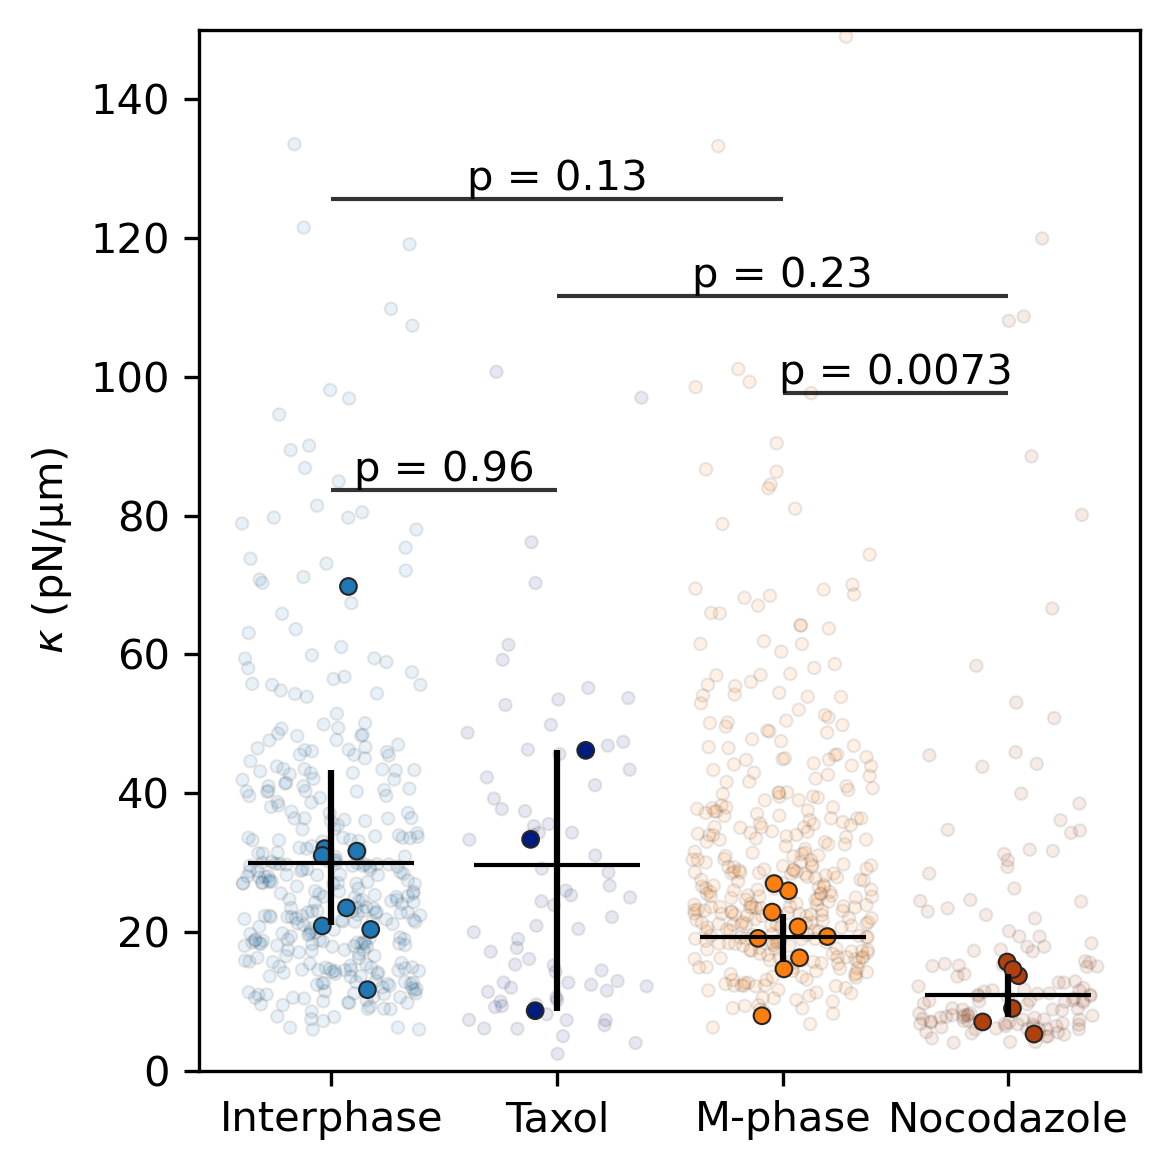

P-value for ('y', 'taxol'): 0.3431566915685067
P-value for ('n', 'noco'): 0.07383884152269383
P-value for ('taxol', 'noco'): 0.07272682126536861
P-value for ('y', 'n'): 0.00986937669892314


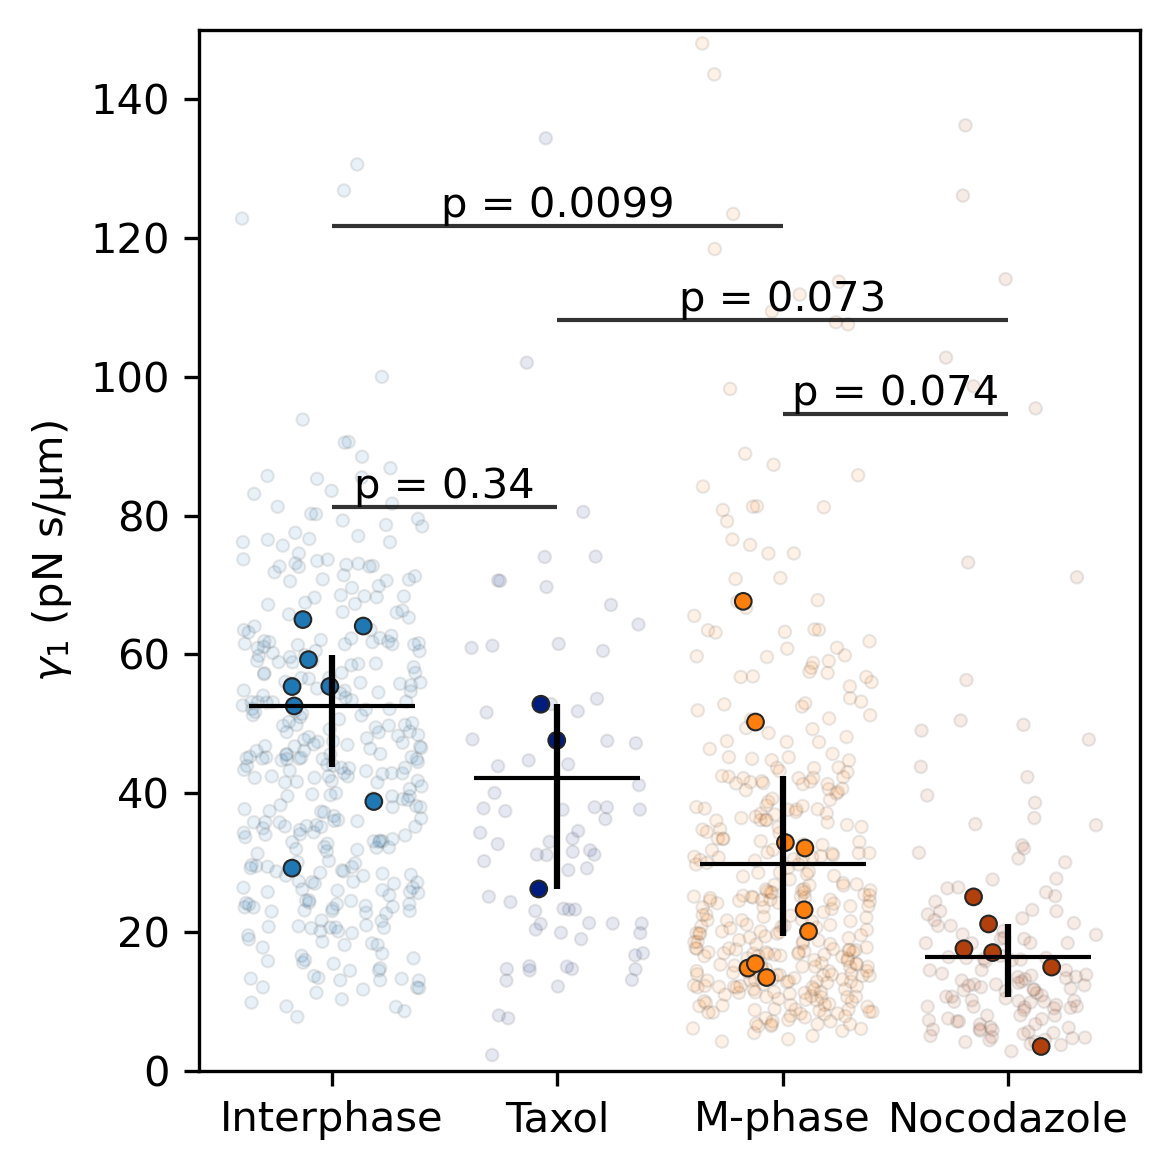

P-value for ('y', 'taxol'): 0.004729178807200581
P-value for ('n', 'noco'): 0.17116816738939758
P-value for ('taxol', 'noco'): 0.035773934703930275
P-value for ('y', 'n'): 0.00013223965685746762


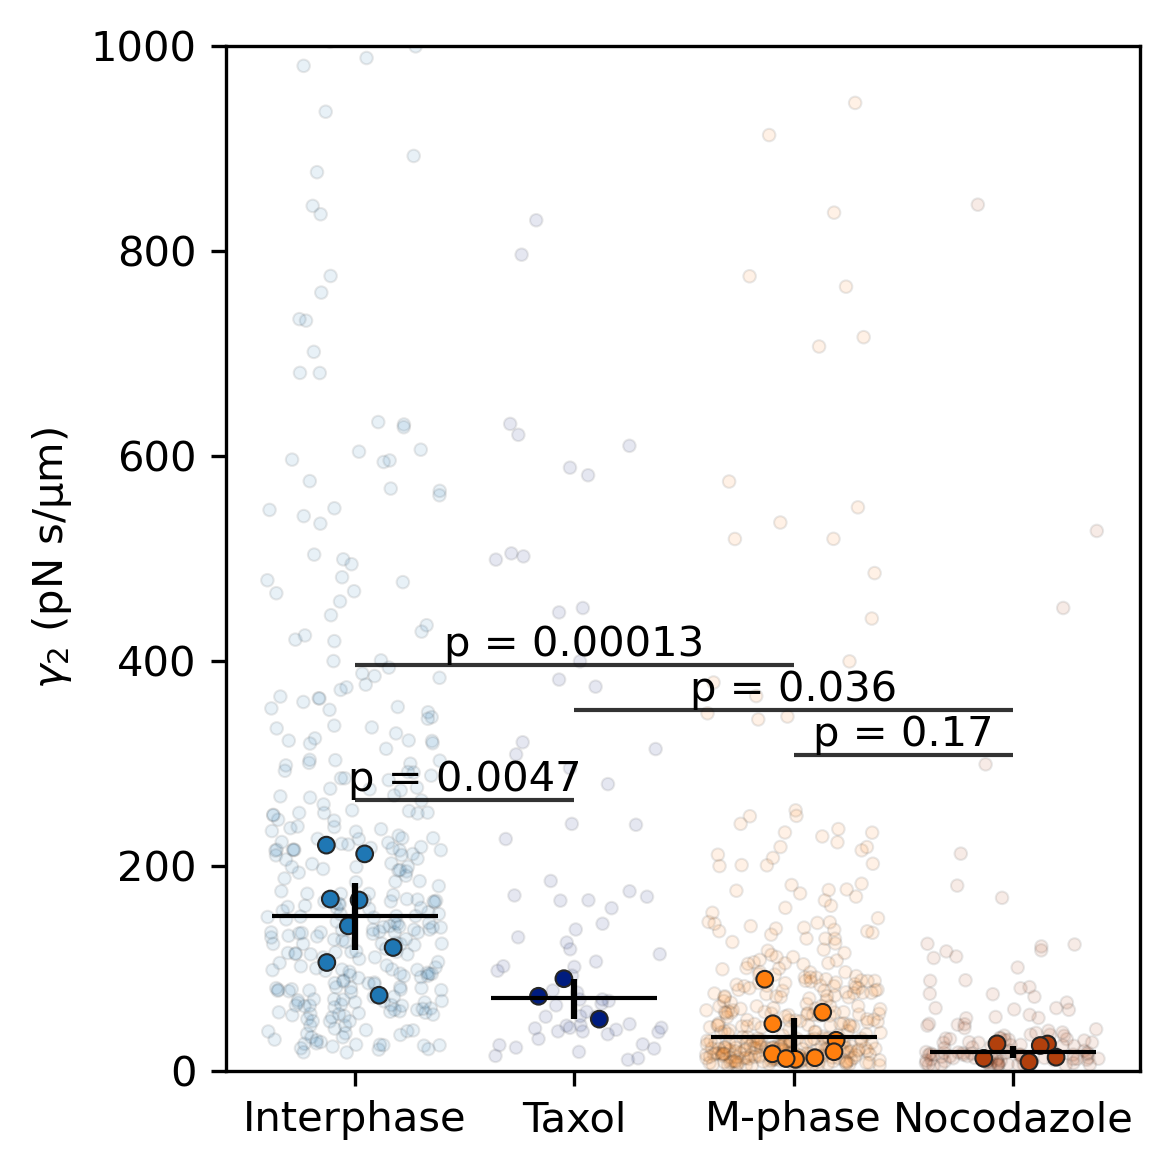

P-value for ('y', 'taxol'): 0.10090564629304664
P-value for ('n', 'noco'): 0.7697347049683788
P-value for ('taxol', 'noco'): 0.2972322466788051
P-value for ('y', 'n'): 0.0002929473082543839


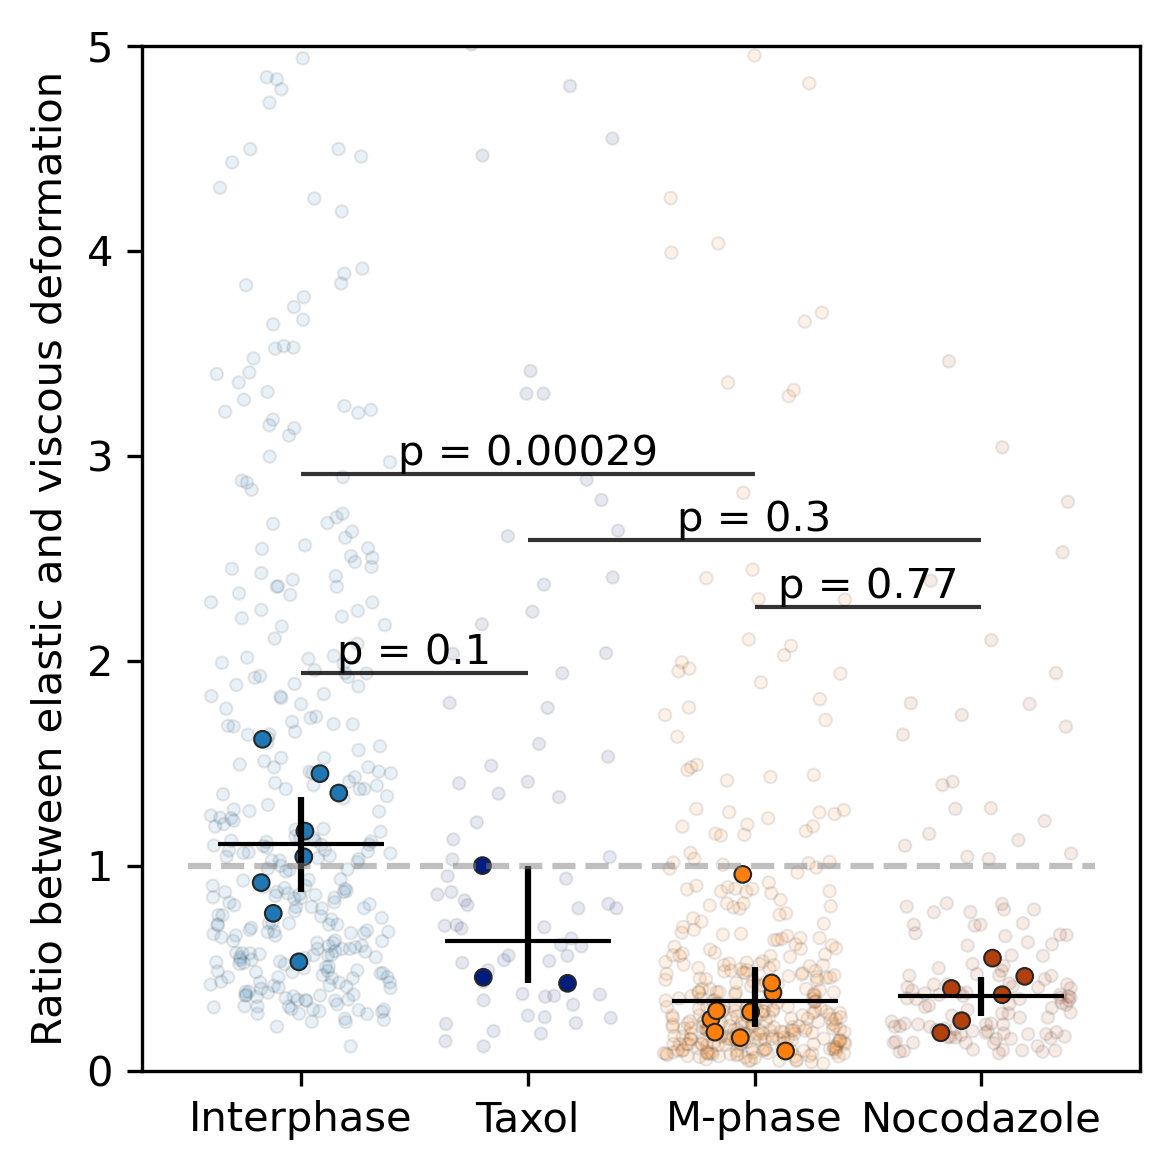

P-value for ('y', 'taxol'): 0.8731120401144149
P-value for ('n', 'noco'): 0.6587178580039637
P-value for ('taxol', 'noco'): 0.010741635762640407
P-value for ('y', 'n'): 0.0028008734196409814


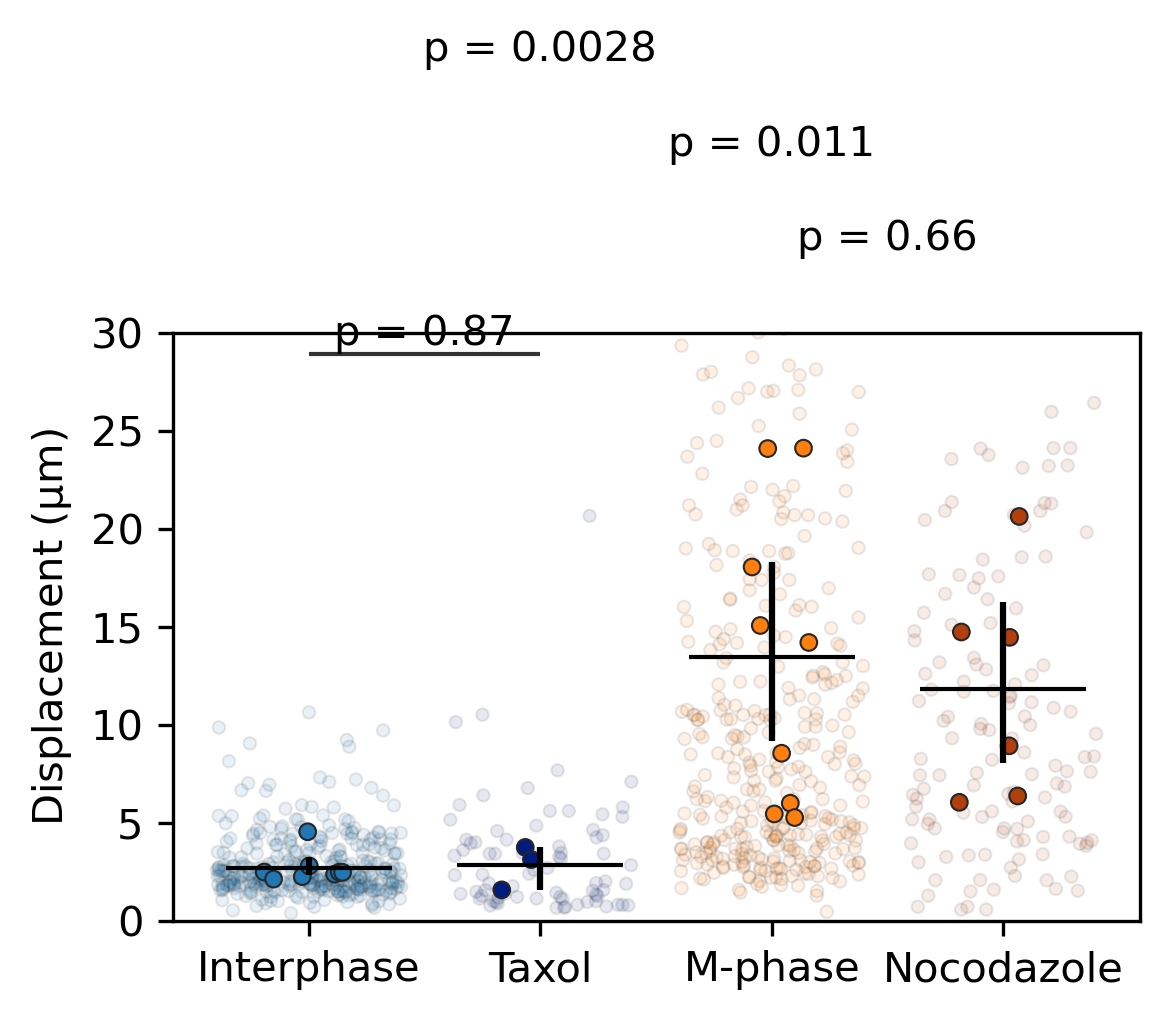

P-value for ('y', 'taxol'): 0.32030702728616095
P-value for ('n', 'noco'): 0.2391814446572949
P-value for ('taxol', 'noco'): 0.009548323147645432
P-value for ('y', 'n'): 0.002900475411510548


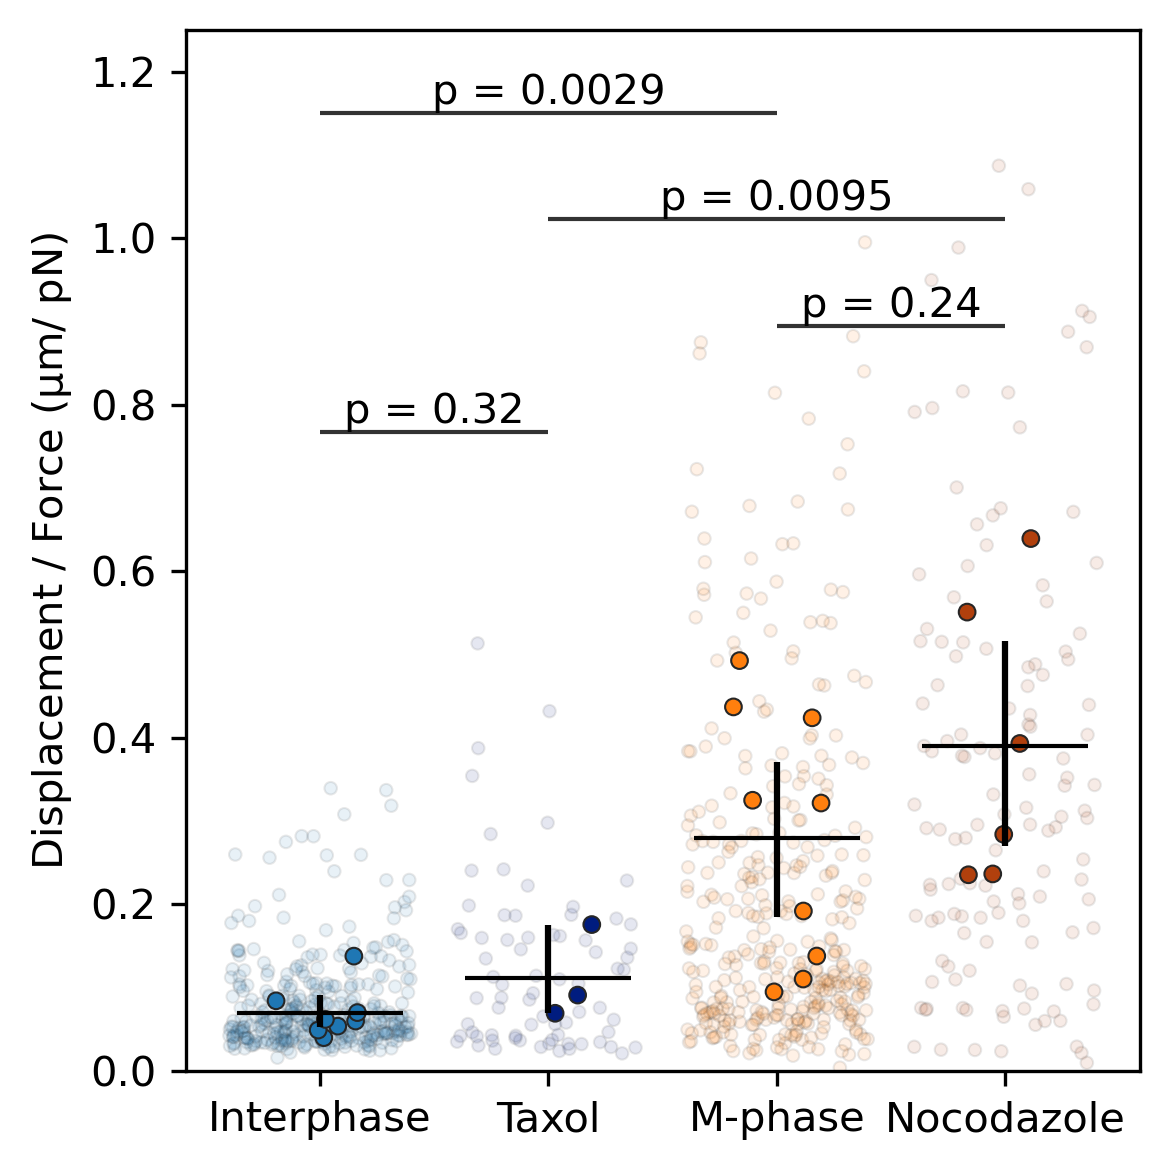

P-value for ('y', 'taxol'): 0.18634564670593654
P-value for ('n', 'noco'): 0.6434814343492872
P-value for ('taxol', 'noco'): 0.47556025273783786
P-value for ('y', 'n'): 0.0004526735685486416


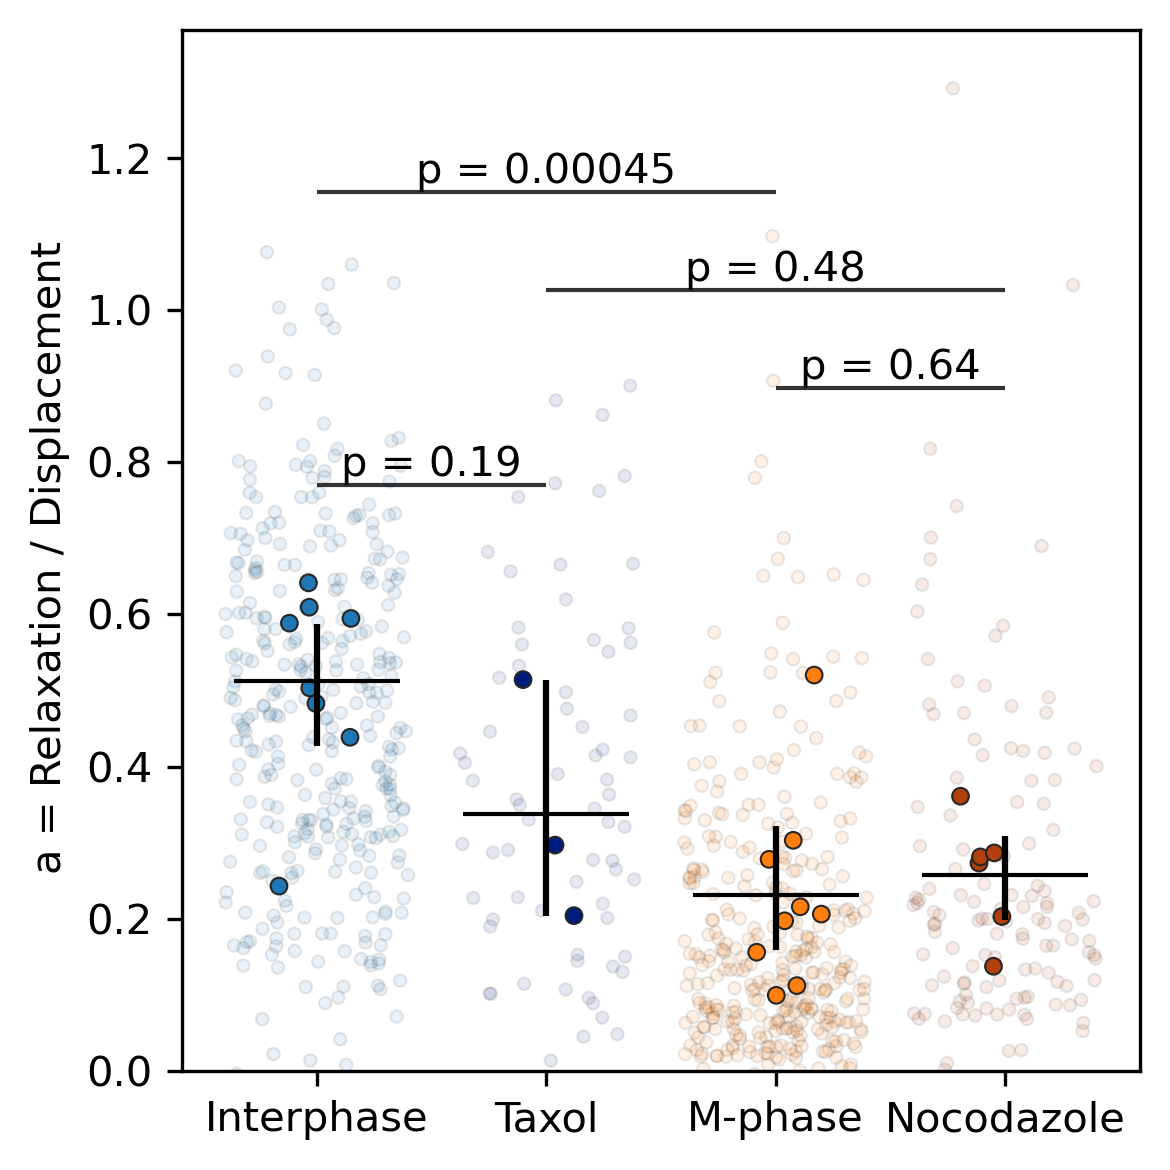

P-value for ('y', 'taxol'): 0.14495989490515357
P-value for ('n', 'noco'): 0.5558421255563872
P-value for ('taxol', 'noco'): 0.23253571961857453
P-value for ('y', 'n'): 5.982326449326358e-05


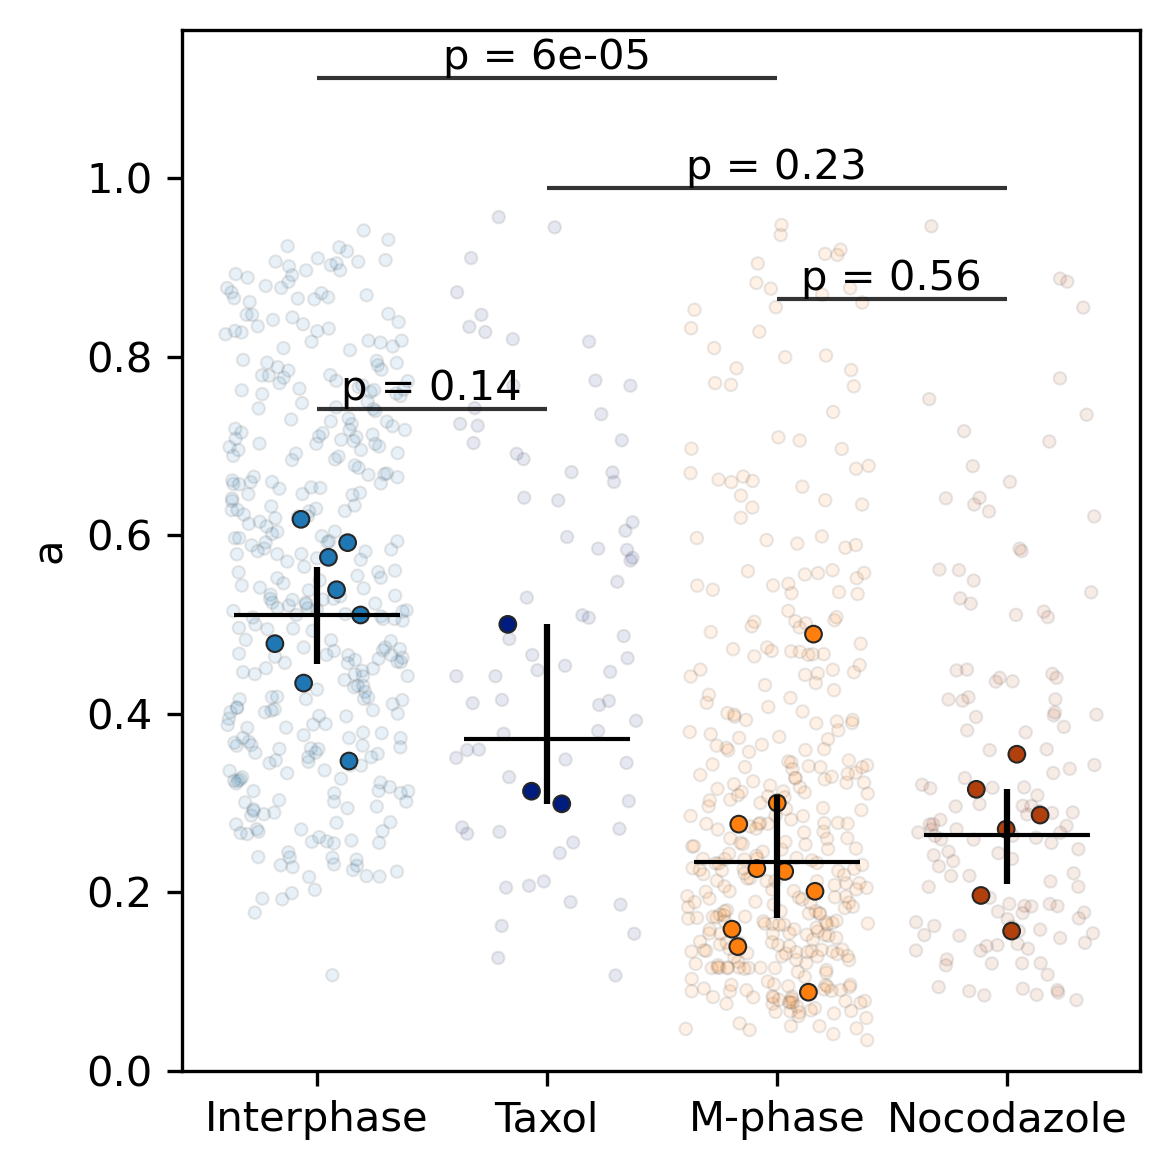

P-value for ('y', 'taxol'): 0.8195315443769762
P-value for ('n', 'noco'): 0.9573276347711976
P-value for ('taxol', 'noco'): 0.6113385589794608
P-value for ('y', 'n'): 0.1718427807189581


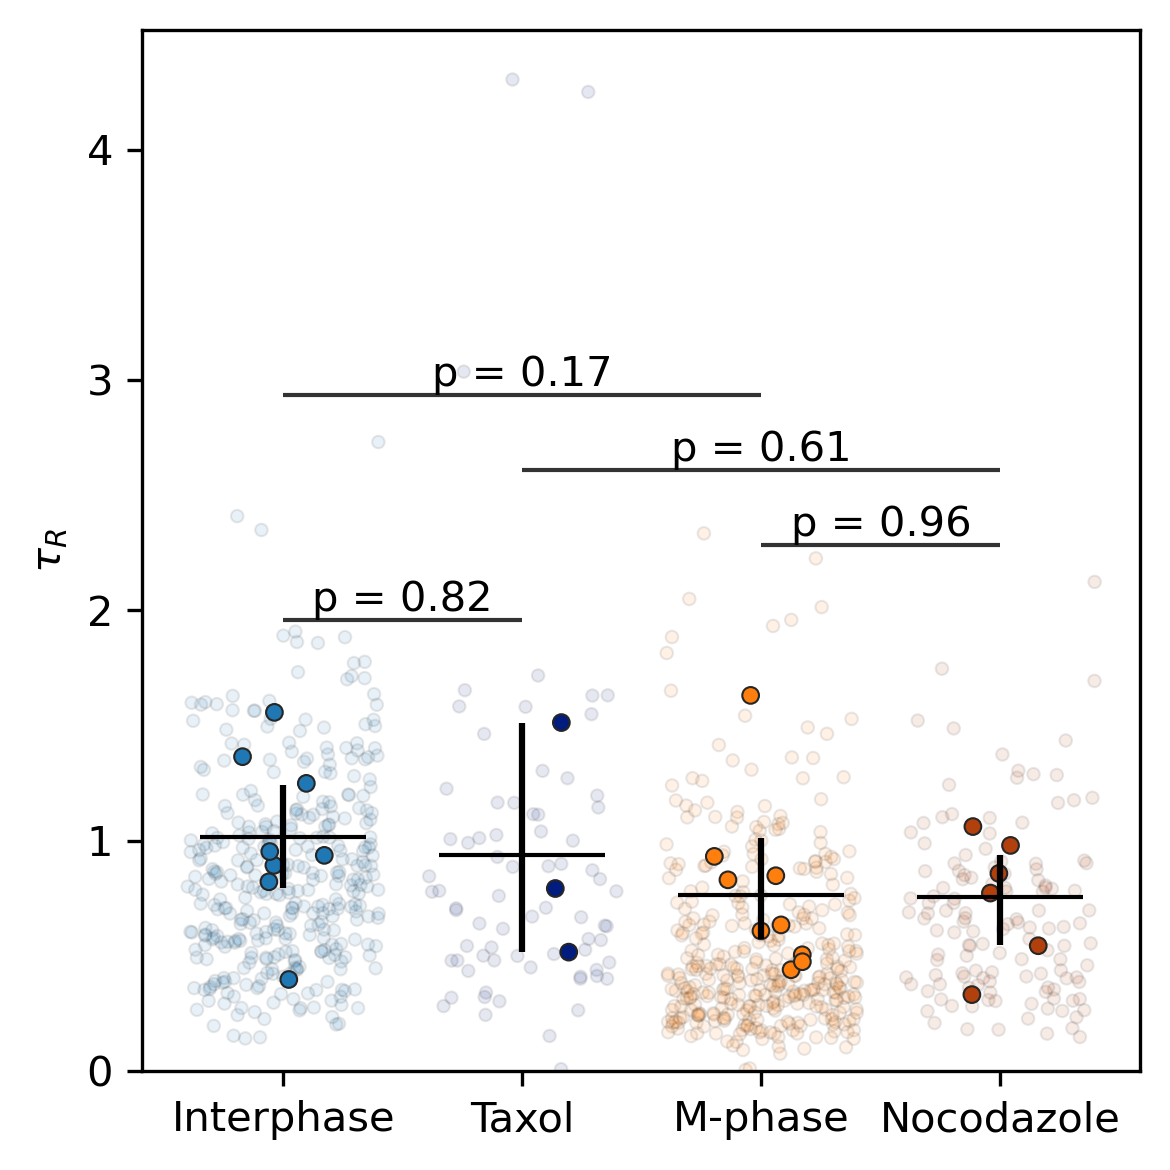

In [32]:
for (param, label) in zip(params, labels):
    fig = plt.figure(figsize=(4, 4), dpi=300)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df_data_all_filtered, jitter=0.4, alpha=0.1, linewidth=0.5, legend=False, size=3, zorder=0, palette=custom_palette)
    sns.stripplot(x='MT_STATUS', y=param, hue='MT_STATUS', data=df_data_avg_curves, jitter=0.2, alpha=1, linewidth=0.5, legend=False, size=4, zorder=1, palette=custom_palette)

    plt.errorbar(df_stats.loc[df_stats['parameter']==param, 'MT_STATUS'], 
                df_stats.loc[df_stats['parameter']==param, 'weighted_average'], 
                yerr=np.array([df_stats.loc[df_stats['parameter']==param, 'y_err_low'].values, df_stats.loc[df_stats['parameter']==param, 'y_err_high'].values]), 
                marker = '_', markersize=40,  color='k', linestyle='', zorder=2)

    # plt.title(f'p = {p_value:.2g}')
    for (i, pair) in enumerate(pairs):
        plot_p_value(param, pair, df_data_avg_curves, custom_dict, height_factor=1.2 + i*0.2)

    plt.ylabel(label)
    plt.xlabel('')
    plt.ylim(bottom=0)
    plt.xticks(ticks=['y', 'taxol', 'n', 'noco'], labels=['Interphase', 'Taxol', 'M-phase', 'Nocodazole'])
    if param == 'k':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_1':
        plt.ylim(bottom=0, top=150)
    elif param == 'eta_2':
        plt.ylim(bottom=0, top=1000)
    elif param == 'rising_dif_norm':
        plt.ylim(0, 1.25)   
    elif param == 'elastic_viscous_ratio':
        plt.ylim(bottom=0, top=5)
        plt.hlines(1, -0.5, 3.5, color='gray', linestyle='--', alpha=0.5)
    elif param == 'rising_dif':
        plt.ylim(bottom=0, top=30)
    # elif param == 'relative_dif':
    #     plt.ylim(bottom=0, top=1)

    # plt.ylim(0, 1000)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f'{dir_plots}/results/result_comparison_{param}_{subtr_bck_label}.svg', format='svg')
    plt.show()